In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
    token="M2-aX5vex7wXH0C38wrlCpg9erqHi8j346bh1uNtVsUI", # Your token is confidential.
    # Do not share your key in public code.
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/22dc8fdbcf474c5c8b2faee4cf250adb:65d65abd-7a76-48da-bda9-c423993173e3::", # Optionally specify the instance to use.
    name="priya", # Optionally name this set of account credentials.
    set_as_default=True, # Optionally set these as your default credentials.
    overwrite=True 
)
service = QiskitRuntimeService()
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
 
# Set up six different observables.
 
observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]
observables = [SparsePauliOp(label) for label in observables_labels]


backend = service.backends(simulator=False, operational=True)[0]

backend = service.least_busy(simulator=False, operational=True)

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
 

qc.draw("mpl")
 
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
 
isa_circuit.draw("mpl", idle_wires=False)

# Construct the Estimator instance.
 
estimator = Estimator(mode=backend)

 
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
 
# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observables)])
 
# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()
 
# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]





>>> Job ID: d1se9issjopc73eu12k0


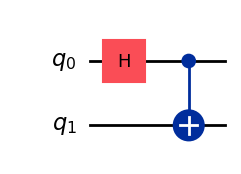

In [5]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
 

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
 

qc.draw("mpl")

